# World Population Forecasting Project
**Goal:** Analyze and forecast global population growth rates, density and historical population from 1970-2022 and provides insights into future population dynamics and regional growth patterns.

**Tools:** Python, Pandas, XGboost(regressor), Scikit-learn, Numpy, SHAP, Matplotlib and Seaborn.

# 1) Importing libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import shap
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

# 2) Loading the dataset

In [2]:
df = pd.read_csv('world_population.csv')
df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


# 3) Cleaning and preprocessing the data

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

In [4]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Rank                           0
CCA3                           0
Country/Territory              0
Capital                        0
Continent                      0
2022 Population                0
2020 Population                0
2015 Population                0
2010 Population                0
2000 Population                0
1990 Population                0
1980 Population                0
1970 Population                0
Area (km²)                     0
Density (per km²)              0
Growth Rate                    0
World Population Percentage    0
dtype: int64


In [5]:
# Definding features and target variable
X = df.drop(columns=[
    '2022 Population', '2020 Population', '2015 Population',
    '2010 Population', '2000 Population', '1990 Population',
    '1980 Population', '1970 Population'
], axis=1)

In [6]:
y = df['2022 Population']

# 4) Exploratory data analysis (EDA)

 **Population distribution by continent**

Text(0.5, 0, 'Continent')

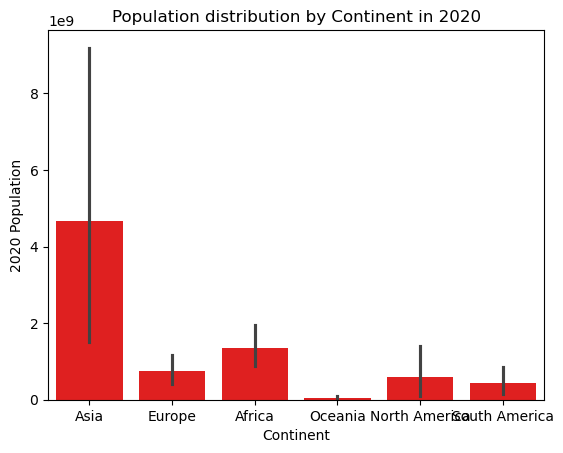

In [7]:
plt.plot(figsize=(10,6))
sns.barplot(x = 'Continent' , y = '2020 Population' , data=df, estimator=sum, color='red')
plt.title('Population distribution by Continent in 2020')
plt.xlabel('Continent')

**Top 20 most populous countries in 2020**

/var/folders/js/3xtrvm0j4hl7jfsbp9htqrc80000gn/T/ipykernel_1217/2395644556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='2020 Population', y='Country/Territory', data=top_20, palette='viridis')


Text(0.5, 0, 'Population')

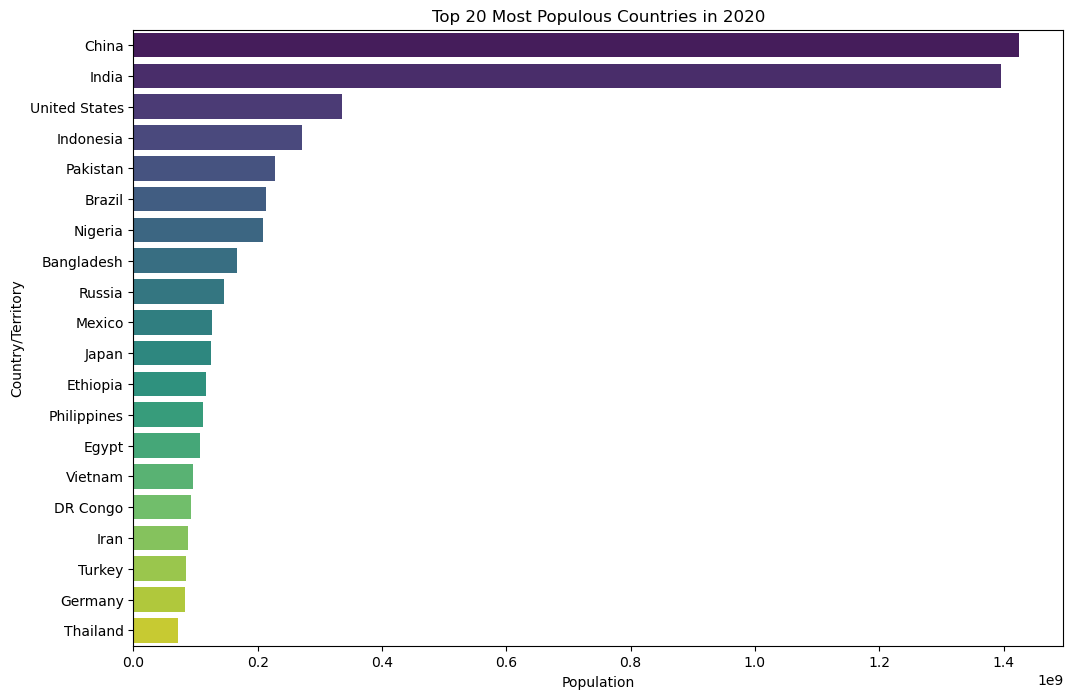

In [8]:
# Top 20 most populous countries in 2020
top_20 = df.sort_values(by='2020 Population', ascending=False).head(20)
plt.figure(figsize=(12,8))
sns.barplot(x='2020 Population', y='Country/Territory', data=top_20, palette='viridis')
plt.title('Top 20 Most Populous Countries in 2020')
plt.xlabel('Population')

**Population growth over time**

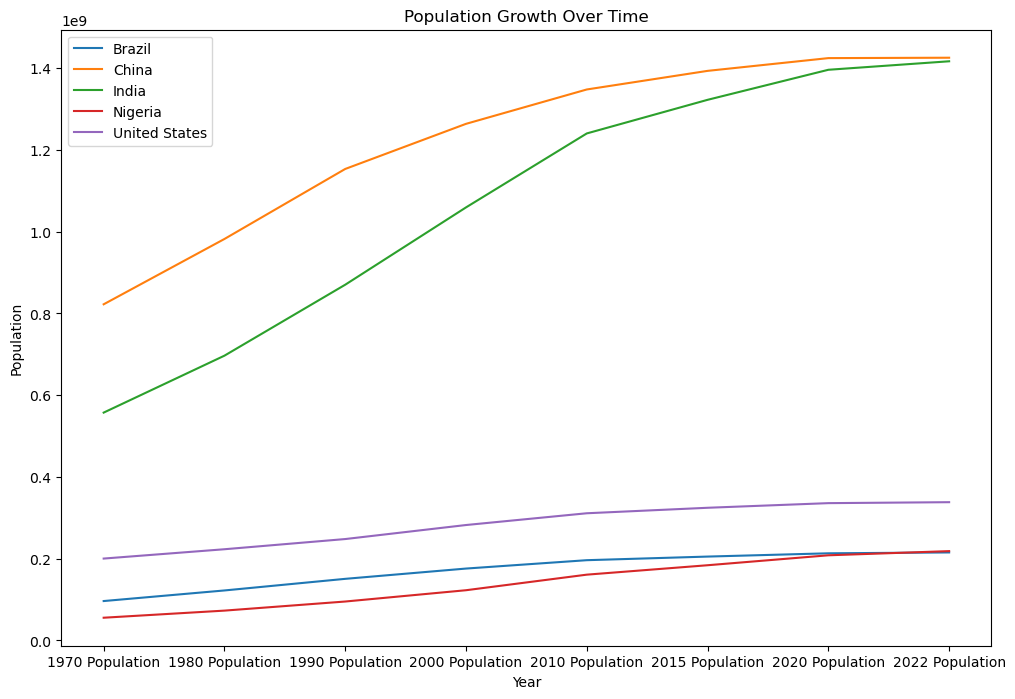

In [9]:
# Population Growth Over Time for Selected Countries
selected_countries = df[df['Country/Territory'].isin(['India', 'China', 'United States', 'Brazil', 'Nigeria'])]
years = ['1970 Population', '1980 Population', '1990 Population', '2000 Population', '2010 Population', '2015 Population', '2020 Population', '2022 Population']
plt.figure(figsize=(12, 8))
for country in selected_countries['Country/Territory']:
    plt.plot(years, selected_countries[selected_countries['Country/Territory'] == country][years].values.flatten(), label=country)
plt.title('Population Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.show()

Population growth distribution in each continent

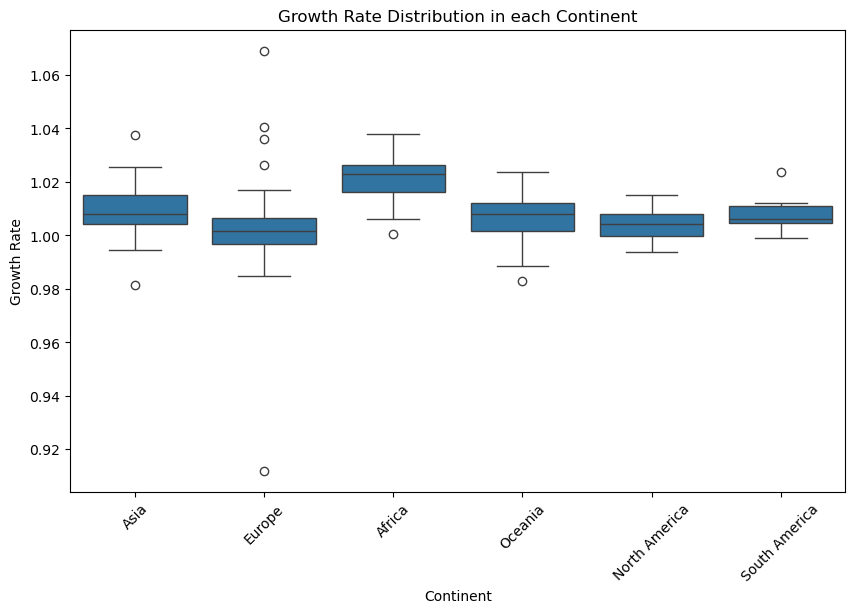

In [10]:
# Population growth distribution in each continent
plt.figure(figsize=(10, 6))
sns.boxplot(x='Continent', y='Growth Rate', data=df)
plt.title('Growth Rate Distribution in each Continent')
plt.xticks(rotation=45)
plt.show()


Top 5 most dense countries

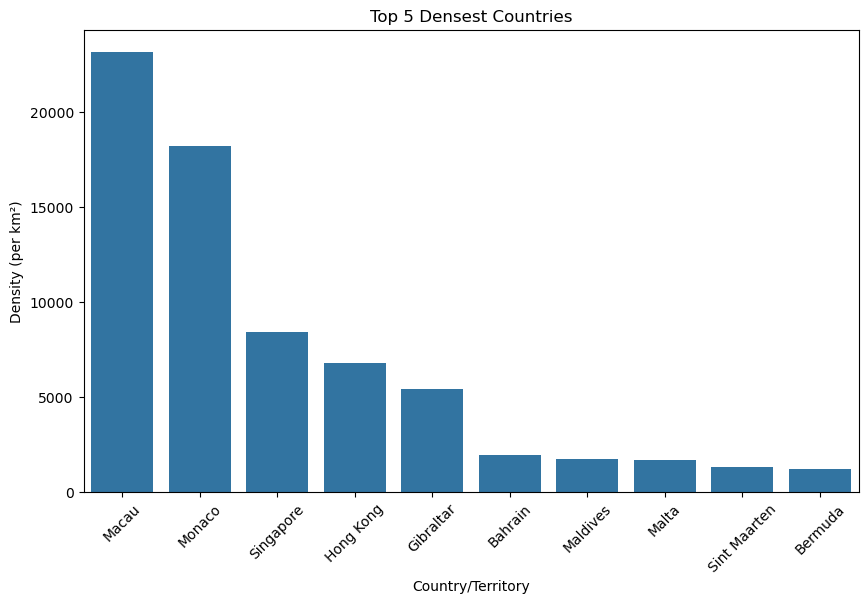

In [11]:
# Top 5 most dense countries
top_5_density = df.nlargest(10, 'Density (per km²)')
plt.figure(figsize=(10, 6))
sns.barplot(x='Country/Territory', y='Density (per km²)', data=top_5_density)
plt.title('Top 5 Densest Countries')
plt.xticks(rotation=45)
plt.show()


Correlation heatmap

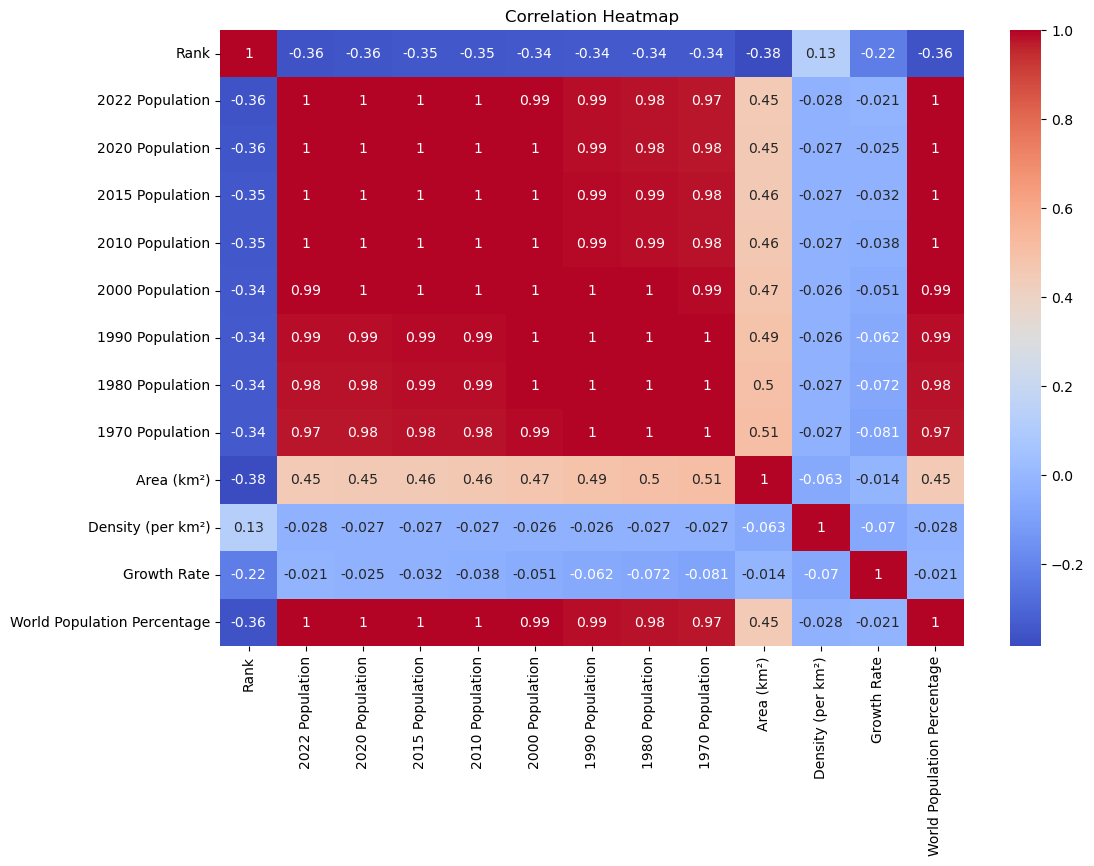

In [12]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Population Growth Rate vs. World Population Percentage

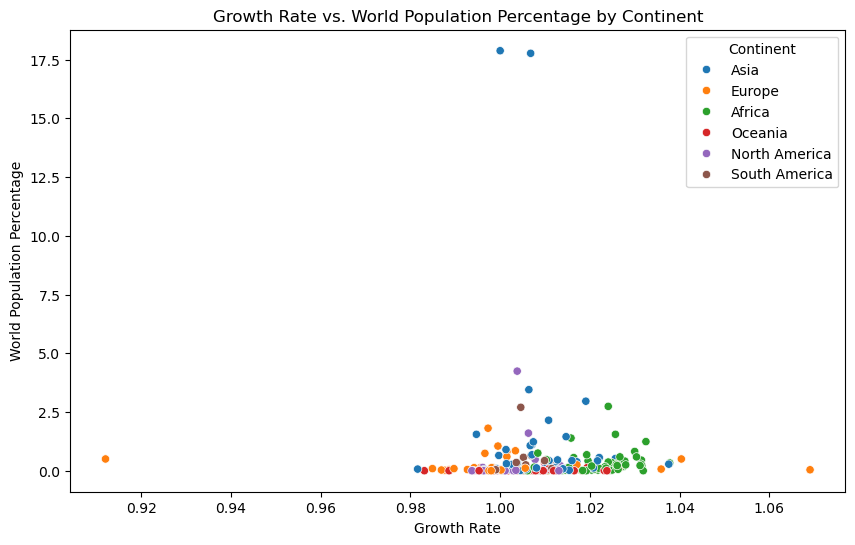

In [13]:
# Scatter plot for Growth Rate vs. World Population Percentage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Growth Rate', y='World Population Percentage', hue='Continent', data=df)
plt.title('Growth Rate vs. World Population Percentage by Continent')
plt.show()

# Feature engineering
I will now be creating new features to capture insights, such as population change based on density from 2015-2022

In [14]:
# Feature engineering a new feature - 'Population Change (2015-2022)'
df['Population Change (2015-2022)'] = df['2022 Population'] - df['2015 Population']

# Feature engineering a new feature - 'Density Change (2015-2022)'
df['Density Change (2015-2022)'] = pd.cut(df['Population Change (2015-2022)'] / (df['Area (km²)'] + 1e-6), bins=5, labels=False)

# Update the dataframe with new features
print(df[['Country/Territory', 'Population Change (2015-2022)', 'Density Change (2015-2022)']].head())

  Country/Territory  Population Change (2015-2022)  Density Change (2015-2022)
0       Afghanistan                        7375272                           0
1           Albania                         -40160                           0
2           Algeria                        5360071                           0
3    American Samoa                          -7095                           0
4           Andorra                           8078                           0


# Splitting the data to train and test set

In [15]:
# Splitting the data to train and test set
X_train, X_test, y_train, y_test = train_test_split(
         X, y, test_size=0.2, random_state=42
)
# checking the shape of the train and test sets
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


X_train: (187, 9), X_test: (47, 9)
y_train: (187,), y_test: (47,)


# Scaling features

In [16]:
# One-hot encode categorical variables
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Align train and test sets
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print(X_train.dtypes)

X_train_scaled shape: (187, 572)
X_test_scaled shape: (47, 572)
Rank                             int64
CCA3                            object
Country/Territory               object
Capital                         object
Continent                       object
Area (km²)                       int64
Density (per km²)              float64
Growth Rate                    float64
World Population Percentage    float64
dtype: object


In [18]:
# Scaling the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Check shapes to confirm everything is okay
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train_scaled shape: (187, 572)
X_test_scaled shape: (47, 572)
y_train shape: (187,)
y_test shape: (47,)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (187, 572)
X_test_scaled shape: (47, 572)


# Model building/training


In [20]:
# Initialising and training the XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
print("✅ XGBoost model trained successfully.")


✅ XGBoost model trained successfully.


In [21]:
# Training the XGBoost model
xgb_model.fit(X_train_scaled, y_train)
print("✅ XGBoost model trained successfully.")

✅ XGBoost model trained successfully.


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# pedicting on scaled and encoded test set
y_pred = xgb_model.predict(X_test_scaled)

# Calculating performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# Displaying the performance 
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 2207984.41
RMSE: 6542540.38


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


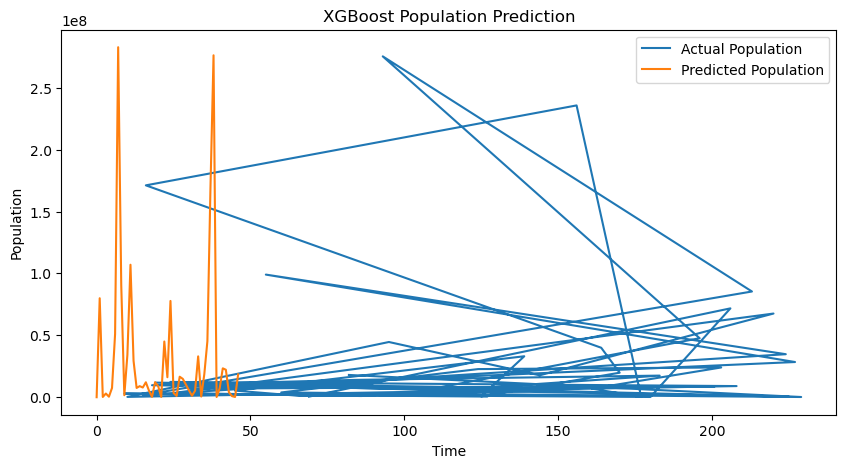

In [23]:
# Visualising Predictions

plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual Population')
plt.plot(y_pred, label='Predicted Population')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('XGBoost Population Prediction')
plt.legend()
plt.show()

# Model evaluation with visuals

In [24]:
# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 2207984.4102
RMSE: 6542540.3756


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


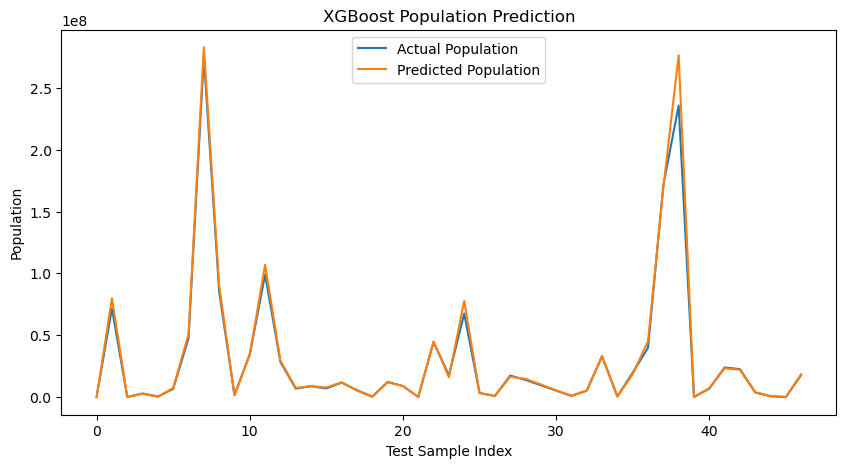

In [25]:
# visualising the results
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test, label='Actual Population')
plt.plot(range(len(y_pred)), y_pred, label='Predicted Population')
plt.xlabel('Test Sample Index')
plt.ylabel('Population')
plt.title('XGBoost Population Prediction')
plt.legend()
plt.show()

In [26]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for your test set
shap_values = explainer.shap_values(X_test_scaled)

# Visualise the summary plot of feature impacts
shap_values = explainer(X_test_scaled)
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(47, 572)


In [27]:
# SHAP explanation (model interpretability)
import shap
shap.initjs()

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_scaled)

# Confirm shapes
print("SHAP values type:", type(shap_values))
print("SHAP values shape:", shap_values.values.shape)
print("Input data shape:", X_test_scaled.shape)
print("Feature names length:", len(X_test_encoded.columns))

SHAP values type: <class 'shap._explanation.Explanation'>
SHAP values shape: (47, 572)
Input data shape: (47, 572)
Feature names length: 572


In [28]:
print("SHAP values shape:", shap_values.values.shape)  
print("Input data shape:", X_test_scaled.shape)      
print("Feature names length:", len(X_test_encoded.columns))    

SHAP values shape: (47, 572)
Input data shape: (47, 572)
Feature names length: 572


In [29]:
print("X_train shape:", X_train.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("shap_values shape:", shap_values.values.shape)

X_train shape: (187, 9)
X_test_scaled shape: (47, 572)
shap_values shape: (47, 572)


In [30]:
shap_values = explainer(X_test_scaled)
print("SHAP values shape after explainer call:", shap_values.values.shape)

SHAP values shape after explainer call: (47, 572)


In [31]:
# Plot SHAP values for the first test sample
shap.force_plot(explainer.expected_value, shap_values.values[0], X_test_scaled[0], feature_names=['Feature1', 'Feature2'])

In [32]:
# Correct: List with 2 items (for your 2 features)
feature_names = ['Year', 'OtherFeature']

shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    X_test_scaled[0],
    feature_names=feature_names
)


In [33]:
print("X_test_scaled shape:", X_test_scaled.shape)            
print("shap_values.values shape:", shap_values.values.shape)  

X_test_scaled shape: (47, 572)
shap_values.values shape: (47, 572)


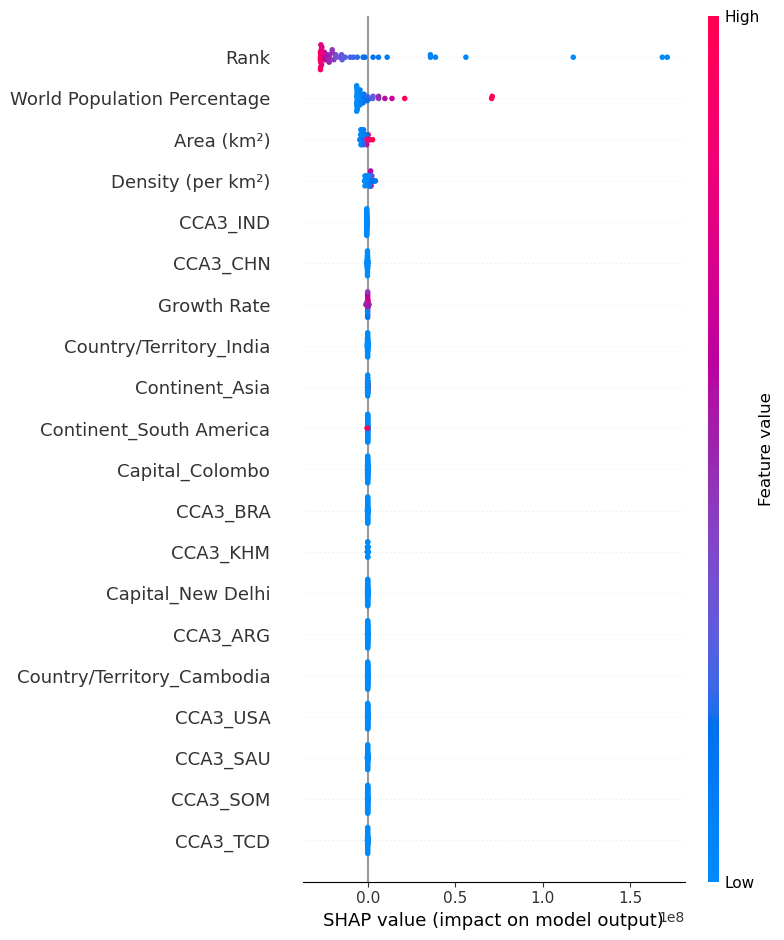

In [34]:
# Visualise the summary plot of feature impacts
shap.summary_plot(shap_values.values, X_test_encoded, feature_names=X_test_encoded.columns)

In [35]:
# 📝 Conclusion
print("✅ Model training, evaluation, and interpretation completed successfully.")

✅ Model training, evaluation, and interpretation completed successfully.
